# Ridge regression: correcting GFS temperature forecasts for RDU

Ridge regression is linear regression with a penalty on the size of the coefficients (controlled by `alpha`). It helps when features are highly correlated, which is the case here (`forecasted_temp`, `forecast_hour`, and their interaction overlap a lot).

**Setup**
- **Target (`y`):** the actual RDU temperature at the hour each forecast is valid for.
- **Features (`X`):** the GFS forecast temperature, lead time (`forecast_hour`), time of day, and a few interactions.
- **Training data:** 5 GFS runs (Sept 16 of 2021-2025), matched to actual observations.
- **Evaluation:** *nested* leave-one-year-out cross-validation. Each year is held out once for testing, and `alpha` is chosen using only the other four years, so the test year never influences the model.
- **Test set:** there are no 2026 actuals in the data yet, so the 2026 predictions are made at the end and a `y_test` placeholder is provided for when the data is pulled.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, LeaveOneGroupOut
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#RAW_DIR      = "/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/data/raw/"
#RAW_DIR  = Path.cwd() / ".." / ".." / ".." / "data" / "raw" / 'RDU_ACTUAL_HISTORICAL.csv'

# Walk up from the notebook until we find the project root (the folder containing "data")
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "raw").is_dir())
RAW_DIR = PROJECT_ROOT / "data" / "raw"
ACTUAL_FILE  = "RDU_ACTUAL_HISTORICAL.csv"
HIST_FILE    = "NOAA_GFS_FORECAST_HISTORICAL.csv"
FUTURE_FILE  = "NOAA_GFS_FORECAST_FUTURE.csv"


## 1. Load and prepare the data

In [7]:
actual_raw = pd.read_csv(RAW_DIR / ACTUAL_FILE, low_memory=False)
hist       = pd.read_csv(RAW_DIR / HIST_FILE)
future     = pd.read_csv(RAW_DIR / FUTURE_FILE)

# ---- Actual temperature per hour (the target) ----
actual = actual_raw[["hour_utc", "temperature_f"]].dropna().copy()
actual["valid_time_utc"] = pd.to_datetime(actual["hour_utc"], utc=True).dt.tz_convert(None)  # UTC, tz-naive
actual = (actual.groupby("valid_time_utc", as_index=False)["temperature_f"].mean()
                .rename(columns={"temperature_f": "actual_temp_f"}))

# ---- Forecast features ----
def prep(df):
    df = df.copy()
    df["gfs_init_utc"]   = pd.to_datetime(df["gfs_init_utc"])
    df["valid_time_utc"] = pd.to_datetime(df["valid_time_utc"])
    df = df.rename(columns={"gfs_temp_f": "gfs_temp"})
    df["year"] = df["gfs_init_utc"].dt.year

    # local (Raleigh) hour of day, encoded as sin/cos so 23:00 and 00:00 are "close"
    local = df["valid_time_utc"].dt.tz_localize("UTC").dt.tz_convert("America/New_York")
    df["hour_sin"] = np.sin(2 * np.pi * local.dt.hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * local.dt.hour / 24)

    # interactions / curvature (scaled so values stay in a similar range)
    lead = df["forecast_hour"] / 100
    df["gfs_x_lead"]  = df["gfs_temp"] * lead      # trust GFS less at long lead times
    df["lead_sq"]     = lead ** 2
    df["gfs_sq"]      = (df["gfs_temp"] / 10) ** 2
    df["gfs_x_sin"]   = df["gfs_temp"] * df["hour_sin"] / 10
    df["gfs_x_cos"]   = df["gfs_temp"] * df["hour_cos"] / 10
    df["lead_x_sin"]  = lead * df["hour_sin"]
    df["lead_x_cos"]  = lead * df["hour_cos"]
    return df

hist, future = prep(hist), prep(future)

train = hist.merge(actual, on="valid_time_utc", how="left")
print("training rows:", len(train), "| missing actuals:", train["actual_temp_f"].isna().sum())
train = train.dropna(subset=["actual_temp_f"]).reset_index(drop=True)
print("2026 forecast rows with actuals available:", future.merge(actual, on="valid_time_utc").shape[0])

y     = train["actual_temp_f"]
years = [int(yr) for yr in sorted(train["year"].unique())]
train.head()

training rows: 930 | missing actuals: 1
2026 forecast rows with actuals available: 0


,gfs_init_utc,forecast_hour,valid_time_utc,gfs_temp,gfs_grid_lat,gfs_grid_lon,year,hour_sin,hour_cos,gfs_x_lead,lead_sq,gfs_sq,gfs_x_sin,gfs_x_cos,lead_x_sin,lead_x_cos,actual_temp_f
0,2021-09-16 18:00:00,10,2021-09-17 04:00:00,72.949989,36.0,281.25,2021,0.000000,1.000000,7.294999,0.0100,53.217009,0.000000,7.294999,0.000000,0.100000,73.94
1,2021-09-16 18:00:00,11,2021-09-17 05:00:00,71.714247,36.0,281.25,2021,0.258819,0.965926,7.888567,0.0121,51.429332,1.856101,6.927064,0.028470,0.106252,73.94
2,2021-09-16 18:00:00,12,2021-09-17 06:00:00,71.451069,36.0,281.25,2021,0.500000,0.866025,8.574128,0.0144,51.052553,3.572553,6.187844,0.060000,0.103923,73.94
3,2021-09-16 18:00:00,13,2021-09-17 07:00:00,69.781917,36.0,281.25,2021,0.707107,0.707107,9.071649,0.0169,48.695159,4.934327,4.934327,0.091924,0.091924,73.94
4,2021-09-16 18:00:00,14,2021-09-17 08:00:00,69.460841,36.0,281.25,2021,0.866025,0.500000,9.724518,0.0196,48.248084,6.015485,3.473042,0.121244,0.070000,73.04


## 2. Feature sets

- **base:** the 5 features from the linear model (GFS temp, lead time, time of day, GFS x lead).
- **rich:** base plus curvature and time-of-day interactions. More features give plain linear regression more room to overfit, which is where ridge is supposed to help.

In [8]:
base_cols = ["gfs_temp", "gfs_x_lead", "forecast_hour", "hour_sin", "hour_cos"]
rich_cols = base_cols + ["lead_sq", "gfs_sq", "gfs_x_sin", "gfs_x_cos", "lead_x_sin", "lead_x_cos"]

# Ridge penalizes coefficients, so features must be on the same scale -> StandardScaler in a pipeline
param_grid = {"ridge__alpha": np.logspace(-3, 3, 25)}

def score(y_true, y_pred):
    return {"RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAE":  mean_absolute_error(y_true, y_pred),
            "R2":   r2_score(y_true, y_pred)}

## 3. Nested leave-one-year-out cross-validation

For each held-out year, ridge picks its own `alpha` by cross-validating across the remaining four years. Plain linear regression (OLS) on the same scaled features is included for comparison.

In [9]:
def nested_loyo(cols, kind):
    preds, alphas = pd.Series(index=train.index, dtype=float), []
    for yr in years:
        is_test = train["year"] == yr
        X_tr, y_tr = train.loc[~is_test, cols], y[~is_test]
        if kind == "ols":
            model = make_pipeline(StandardScaler(), LinearRegression()).fit(X_tr, y_tr)
        else:
            model = GridSearchCV(make_pipeline(StandardScaler(), Ridge()), param_grid,
                                 cv=LeaveOneGroupOut(), scoring="neg_root_mean_squared_error")
            model.fit(X_tr, y_tr, groups=train.loc[~is_test, "year"])
            alphas.append(float(model.best_params_["ridge__alpha"]))
        preds[is_test] = model.predict(train.loc[is_test, cols])
    return preds, alphas

runs = {
    "OLS, base features":   (base_cols, "ols"),
    "Ridge, base features": (base_cols, "ridge"),
    "OLS, rich features":   (rich_cols, "ols"),
    "Ridge, rich features": (rich_cols, "ridge"),
}

rows = [{"model": "Baseline: raw GFS", **score(y, train["gfs_temp"])}]
oof, chosen_alphas = {}, {}
for name, (cols, kind) in runs.items():
    oof[name], chosen_alphas[name] = nested_loyo(cols, kind)
    rows.append({"model": name, **score(y, oof[name])})

cv_results = pd.DataFrame(rows).set_index("model").round(3)
display(cv_results)

print("alpha chosen per held-out year (", years, "):")
for name, a in chosen_alphas.items():
    if a: print(f"  {name}: {[round(x, 3) for x in a]}")

/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: o

,RMSE,MAE,R2
model,,,
Baseline: raw GFS,5.753,4.303,0.491
"OLS, base features",4.971,3.749,0.620
"Ridge, base features",4.988,3.764,0.617
"OLS, rich features",4.986,3.737,0.618
"Ridge, rich features",4.974,3.701,0.620


alpha chosen per held-out year ( [2021, 2022, 2023, 2024, 2025] ):
  Ridge, base features: [0.316, 1.778, 1.778, 0.562, 1.778]
  Ridge, rich features: [0.562, 0.562, 0.1, 0.562, 0.562]


## 4. How sensitive is the model to alpha?

CV error across alpha values, using all five years. A flat curve means the penalty barely matters; a clear dip means regularization is helping.

/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/jothigupta

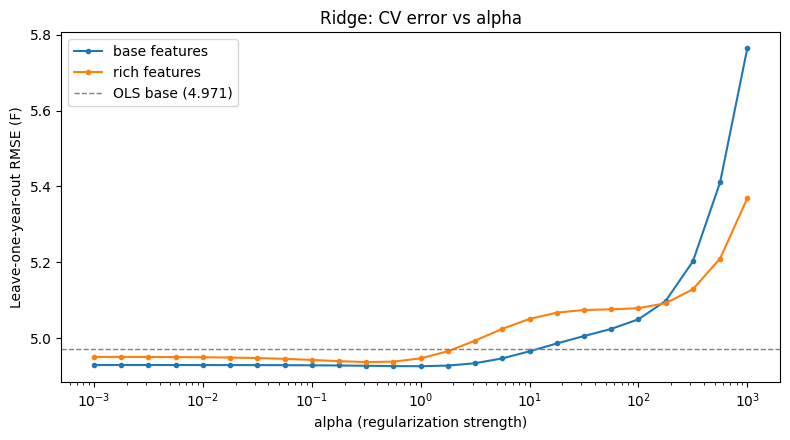

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for label, cols in [("base features", base_cols), ("rich features", rich_cols)]:
    gs = GridSearchCV(make_pipeline(StandardScaler(), Ridge()), param_grid,
                      cv=LeaveOneGroupOut(), scoring="neg_root_mean_squared_error")
    gs.fit(train[cols], y, groups=train["year"])
    ax.plot(param_grid["ridge__alpha"], -gs.cv_results_["mean_test_score"], marker="o", ms=3, label=label)

ols_rmse = cv_results.loc["OLS, base features", "RMSE"]
ax.axhline(ols_rmse, color="gray", ls="--", lw=1, label=f"OLS base ({ols_rmse})")
ax.set(xscale="log", xlabel="alpha (regularization strength)", ylabel="Leave-one-year-out RMSE (F)",
       title="Ridge: CV error vs alpha")
ax.legend(); plt.tight_layout(); plt.show()

## 5. Final ridge model

The better ridge feature set (by cross-validated RMSE) is refit on all 2021-2025 data, with `alpha` chosen by leave-one-year-out CV. Coefficients are on standardized features so their sizes are comparable.

In [11]:
ridge_only = cv_results.loc[["Ridge, base features", "Ridge, rich features"], "RMSE"]
best_name  = ridge_only.idxmin()
best_cols  = rich_cols if "rich" in best_name else base_cols
print("Best ridge model:", best_name)

final_ridge = GridSearchCV(make_pipeline(StandardScaler(), Ridge()), param_grid,
                           cv=LeaveOneGroupOut(), scoring="neg_root_mean_squared_error")
final_ridge.fit(train[best_cols], y, groups=train["year"])
print("alpha:", round(float(final_ridge.best_params_["ridge__alpha"]), 4))

final_ols = make_pipeline(StandardScaler(), LinearRegression()).fit(train[best_cols], y)

coef_table = pd.DataFrame({
    "OLS":   final_ols.named_steps["linearregression"].coef_,
    "Ridge": final_ridge.best_estimator_.named_steps["ridge"].coef_,
}, index=best_cols).round(3)
display(coef_table)

Best ridge model: Ridge, rich features
alpha: 0.3162


/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/jothigupta

,OLS,Ridge
gfs_temp,13.454,10.380
gfs_x_lead,-16.844,-14.504
forecast_hour,19.385,16.812
hour_sin,-2.974,-4.093
hour_cos,-0.101,-1.204
lead_sq,-3.187,-2.966
gfs_sq,-5.925,-3.201
gfs_x_sin,2.961,3.882
gfs_x_cos,-1.350,-0.388
lead_x_sin,-1.326,-1.064


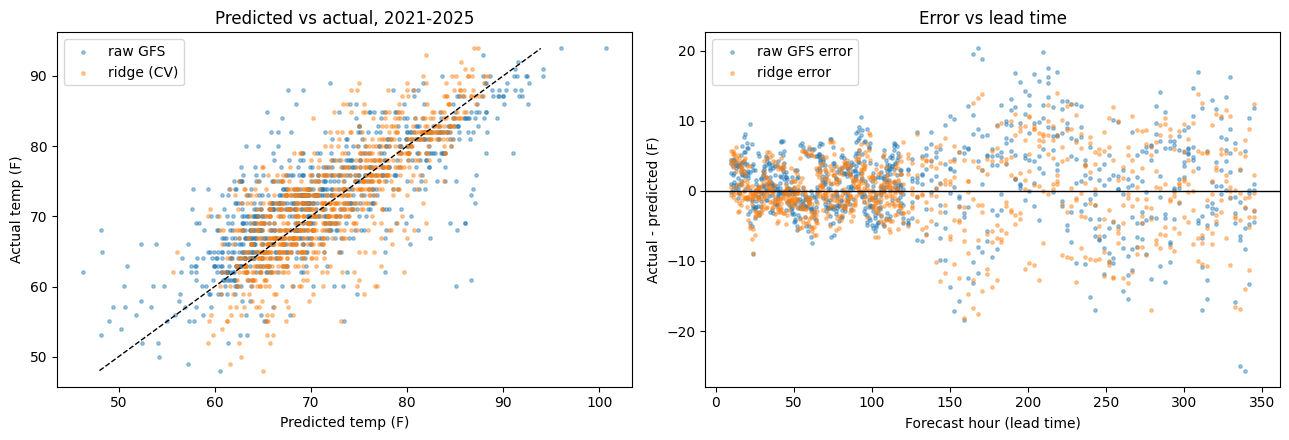

,raw GFS,ridge
forecast_hour,,
"(0, 48]",3.14,2.78
"(48, 120]",3.60,3.00
"(120, 240]",8.26,7.02
"(240, 400]",7.78,6.94


In [12]:
# ---- Diagnostics ----
best_oof = oof[best_name]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].scatter(train["gfs_temp"], y, s=6, alpha=0.4, label="raw GFS")
ax[0].scatter(best_oof, y, s=6, alpha=0.4, label="ridge (CV)")
lims = [y.min(), y.max()]; ax[0].plot(lims, lims, "k--", lw=1)
ax[0].set(xlabel="Predicted temp (F)", ylabel="Actual temp (F)", title="Predicted vs actual, 2021-2025")
ax[0].legend()

ax[1].scatter(train["forecast_hour"], y - train["gfs_temp"], s=6, alpha=0.4, label="raw GFS error")
ax[1].scatter(train["forecast_hour"], y - best_oof, s=6, alpha=0.4, label="ridge error")
ax[1].axhline(0, color="k", lw=1)
ax[1].set(xlabel="Forecast hour (lead time)", ylabel="Actual - predicted (F)", title="Error vs lead time")
ax[1].legend()
plt.tight_layout(); plt.show()

bucket = pd.cut(train["forecast_hour"], [0, 48, 120, 240, 400])
rmse = lambda e: np.sqrt((e ** 2).mean())
pd.DataFrame({
    "raw GFS": (y - train["gfs_temp"]).groupby(bucket, observed=True).apply(rmse),
    "ridge":   (y - best_oof).groupby(bucket, observed=True).apply(rmse),
}).round(2)

## 6. Predictions for 2026

/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,valid_time_utc,forecast_hour,gfs_temp,predicted_temp_f
0,2026-09-17 04:00:00,10,69.389924,68.553967
1,2026-09-17 05:00:00,11,68.854451,68.077031
2,2026-09-17 06:00:00,12,67.350587,66.916266
3,2026-09-17 07:00:00,13,66.622139,66.526204
4,2026-09-17 08:00:00,14,65.846943,66.217956


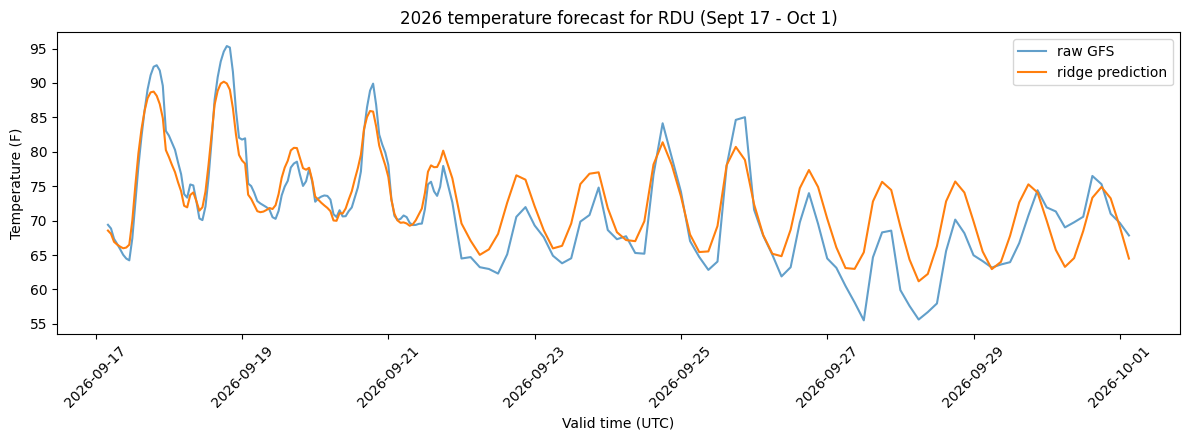

In [13]:
future["predicted_temp_f"] = final_ridge.predict(future[best_cols])
pred_2026 = future[["valid_time_utc", "forecast_hour", "gfs_temp", "predicted_temp_f"]]
display(pred_2026.head())

plt.figure(figsize=(12, 4.5))
plt.plot(pred_2026["valid_time_utc"], pred_2026["gfs_temp"], label="raw GFS", alpha=0.7)
plt.plot(pred_2026["valid_time_utc"], pred_2026["predicted_temp_f"], label="ridge prediction")
plt.title("2026 temperature forecast for RDU (Sept 17 - Oct 1)")
plt.xlabel("Valid time (UTC)"); plt.ylabel("Temperature (F)")
plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

# pred_2026.to_csv("rdu_2026_ridge_predictions.csv", index=False)   # uncomment to save

## 7. 2026 test set (to be filled in)

The actuals file currently ends right before the 2026 forecast window starts, so there is no real test data yet. Fill in `y_test` once the data is pulled and the cell below it scores the predictions.

In [14]:
# Expected format: one row per hour, with
#   valid_time_utc : hourly timestamp in UTC, tz-naive (same as the forecasts)
#   actual_temp_f  : observed RDU temperature in F
y_test = pd.DataFrame({"valid_time_utc": pd.Series(dtype="datetime64[ns]"),
                       "actual_temp_f":  pd.Series(dtype="float64")})

# Once you have the new actuals file, uncomment and adjust the path:
# new_actuals = pd.read_csv("path/to/RDU_ACTUAL_2026.csv", low_memory=False)
# new_actuals["hour_utc"] = pd.to_datetime(new_actuals["hour_utc"], utc=True).dt.tz_convert(None)
# y_test = (new_actuals[["hour_utc", "temperature_f"]].dropna()
#           .groupby("hour_utc", as_index=False)["temperature_f"].mean()
#           .rename(columns={"hour_utc": "valid_time_utc", "temperature_f": "actual_temp_f"}))

In [15]:
# Scores the 2026 predictions against y_test. Skips itself while y_test is empty.
test_eval = future.merge(y_test, on="valid_time_utc", how="inner")

if test_eval.empty:
    print("y_test is empty -- fill it in above, then re-run this cell.")
else:
    print(f"Scoring on {len(test_eval)} forecast hours from 2026")
    comparison = pd.DataFrame({
        "Baseline: raw GFS": score(test_eval["actual_temp_f"], test_eval["gfs_temp"]),
        f"Ridge ({best_name})": score(test_eval["actual_temp_f"], test_eval["predicted_temp_f"]),
    }).T.round(3)
    display(comparison)

    plt.figure(figsize=(12, 4.5))
    plt.plot(test_eval["valid_time_utc"], test_eval["actual_temp_f"], "k", label="actual")
    plt.plot(test_eval["valid_time_utc"], test_eval["gfs_temp"], alpha=0.7, label="raw GFS")
    plt.plot(test_eval["valid_time_utc"], test_eval["predicted_temp_f"], label="ridge prediction")
    plt.title("2026: actual vs predicted"); plt.xlabel("Valid time (UTC)"); plt.ylabel("Temperature (F)")
    plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

y_test is empty -- fill it in above, then re-run this cell.
